#### What is a Histogram (histplot)?
A histogram is a type of bar chart that displays the frequency distribution of a continuous numerical variable. It does this by dividing the entire range of the data into a series of intervals—called bins—and then counting how many data points fall into each bin.

The height of each bar represents the number of observations (frequency) within that bin. It provides a visual representation of the data's underlying probability distribution.

Key Difference from a Bar Chart: A bar chart is used for categorical data, where each bar represents a distinct category. A histogram is used for numerical data, where each bar represents a continuous range of values.

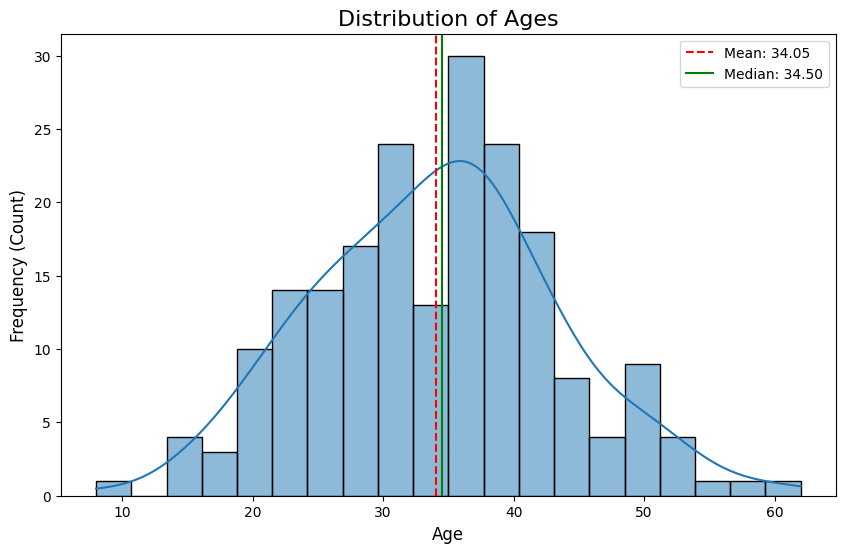

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Sample Data
# Generate 200 random ages, centered around 35 with a standard deviation of 10
np.random.seed(42) # for reproducibility
ages = np.random.normal(loc=35, scale=10, size=200).astype(int)
# Ensure no negative ages
ages = np.clip(ages, 0, 100)
df = pd.DataFrame({'age': ages})

# 2. Sample Code for the Plot
plt.figure(figsize=(10, 6))

# Create the histogram using seaborn's histplot
# data: The DataFrame
# x: The numerical column to plot
# bins: The number of bins to divide the data into. 'auto' is a good start.
# kde: If True, overlays a Kernel Density Estimate (a smoothed line) on the plot.
sns.histplot(
    data=df,
    x='age',
    bins=20, # We can specify the number of bins
    kde=True # Overlay a smooth density curve
)

# Add a vertical line for the mean to provide context
plt.axvline(x=df['age'].mean(), color='red', linestyle='--', label=f"Mean: {df['age'].mean():.2f}")
plt.axvline(x=df['age'].median(), color='green', linestyle='-', label=f"Median: {df['age'].median():.2f}")

# Add title and labels for clarity
plt.title('Distribution of Ages', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)
plt.legend()
plt.show()

#### What Type of Information It Provides
A histogram is the primary tool for Univariate Analysis of a numerical variable. It answers the question: "What does the distribution of this feature look like?"

Central Tendency: Where is the "center" of the data? You can visually estimate the mean, median, and mode.

Mode: The tallest bar in the histogram represents the most frequent range of values.
Shape of the Distribution:

Symmetric (Normal/Bell-Shaped): The left and right sides are mirror images. The mean and median are very close. Our example is roughly symmetric.

Skewed Right (Positively Skewed): A long "tail" extends to the right. The mean is greater than the median. (e.g., income).

Skewed Left (Negatively Skewed): A long "tail" extends to the left. The mean is less than the median. (e.g., age at retirement).

Bimodal / Multimodal: The histogram has two or more distinct peaks, suggesting there might be multiple underlying sub-groups in the data.

Spread / Dispersion: How spread out are the values? A wide histogram indicates high variance, while a narrow one indicates low variance.

Outliers: Outliers will appear as isolated bars far away from the main body of the data.

Gaps: Gaps in the histogram can indicate unusual data or data collection issues where no values were recorded in a certain range.

#### Scenarios for Using a Histogram
A histogram is a go-to plot at the beginning of any data analysis project.

##### During Exploratory Data Analysis (EDA)
Understanding Feature Distributions: This is its primary and most crucial role. Before applying any machine learning model, you must understand the nature of your features.

Example: Plotting a histogram of price to see if it's normally distributed or heavily skewed.

Identifying Skewness: To visually confirm if a feature is skewed, which helps you decide if a transformation (like a log transform) is necessary.

Detecting Outliers: To spot values that are far from the central mass of the data.

Checking for Multiple Modes: To see if your data is composed of distinct sub-groups (e.g., a histogram of heights might show two peaks, one for men and one for women).

Comparing Distributions with hue: You can use the hue parameter to overlay histograms for different categories, allowing you to compare their distributions.

Example: sns.histplot(data=df, x='income', hue='education_level') to see if income distributions differ by education.

##### During Model Diagnostics and Evaluation (Post-Model Generation)
Analyzing Model Residuals (Errors):

What: After training a regression model, you calculate the errors (Actual - Predicted) and plot a histogram of these errors.

Why: A key assumption of many linear models is that the errors are normally distributed and centered around zero. A histogram of the residuals provides a quick visual check of this assumption. If the histogram of errors is skewed or not centered at zero, it indicates a problem with your model.

##### Data Quality and Sanity Checking
Spotting Impossible Values: A histogram can quickly reveal data quality issues.

Example: A histogram of age showing a bar at -10 or 200 immediately tells you there are errors in your data.

Understanding the Impact of Binning: Before you bin a numerical feature, a histogram shows you where the data is concentrated, helping you make a more informed decision about where to place your bin edges.